# Black-Box — a quantitative teardown 🔬
### In-sample vs walk-forward OOS · the cost wall · the shuffled-label control · the deflated-Sharpe caveat

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfit?: Confirmed](https://img.shields.io/badge/Overfit%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: a neural net finds nonlinear structure in crypto prices. We confirm it scores beautifully **in-sample** (Sharpe 5.38, accuracy 0.664), show the **walk-forward** out-of-sample edge is `NONE` (accuracy 0.512 ≈ coin-flip), `MIRAGE` net of costs, and prove the in-sample number is `CONFIRMED` overfitting with a shuffled-label control — the machine-learning mirror of Study 22's look-ahead trap.

> ⚠️ **Not investment advice.** The core executes on a synthetic series with a *known* weak signal (positive control) and a random-walk null; the real crypto run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from black_box import data, strategy, costs, extension

# Offline synthetic control: a series with a weak NONLINEAR lagged signal (so an MLP CAN learn it) + a
# pure random-walk null (nothing to learn). The real BTC/ETH/LTC/XRP verdict is in ../docs/results.md.
NET = dict(hidden=(16, 8), max_iter=250)
WF = dict(min_train=400, step=200, **NET)
df, truth = data.synthetic_predictable(predictable_strength=0.015, n_bars=1200, seed=39)
df0, _ = data.synthetic_predictable(predictable_strength=0.0, n_bars=1200, seed=39)
close, close0 = df["close"], df0["close"]
print(f"synthetic control: {truth.n_bars} days, predictable_strength {truth.predictable_strength} (null=0)")


synthetic control: 1200 days, predictable_strength 0.015 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — real out-of-sample? | 🔴 `NONE` | Walk-forward OOS Sharpe **0.90**, accuracy **0.512** (≈ 0.5). In-sample Sharpe **5.38** is the trap. |
| **Tradability** | 🔴 `MIRAGE` | Net @10 bp **0.36**; no gross OOS edge to erode. |
| **Overfit?** | ⚪ `Confirmed` | The net fits **shuffled** labels in-sample (train acc **0.664** ≈ shuffled **0.67**, vs 0.5). |

> **In one sentence:** an MLP scores a gorgeous in-sample Sharpe on crypto OHLCV that collapses to a coin-flip out-of-sample and is negative after costs — the in-sample number was the net memorising noise, proven by the shuffled-label control.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Features $X_t$ are strictly lagged functions of past returns (the last $k$ returns, trailing momentum, realised vol, a z-score), so the row for day $t$ uses only information available at the close of $t-1$. The target is $y_t = \mathbb{1}[r_t > 0]$. An MLP classifier $f$ is fit on $\{(X_s, y_s)\}$ and the position is $\text{sign}(2f(X_t)-1)$. **In-sample:** fit and predict on the *same* $\{s\}$. **Walk-forward:** fit on $s<\tau$, predict $\tau \le s < \tau+h$, advance $\tau$. Null: an i.i.d. random walk — $y_t$ is independent of $X_t$.

In [2]:
for label, c in [('signal control', close), ('null', close0)]:
    pos = strategy.walk_forward_predictions(c, **WF)
    s = strategy.summary(strategy.book_returns(c, pos, cost_bps=0.0))
    print(f"{label:16} OOS Sharpe {s['sharpe']:+6.2f}  accuracy {strategy.accuracy(c, pos):.3f}")

signal control   OOS Sharpe  +2.66  accuracy 0.563


null             OOS Sharpe  -0.67  accuracy 0.474


> 💡 **In plain words.** The control's returns carry a real (if weak) lagged nonlinear signal, so the net recovers a *positive* OOS Sharpe — it genuinely can learn structure when structure exists. The null has none, so OOS is ~0. That validates the apparatus: when it finds nothing OOS on real crypto, the *crypto* has no learnable daily-direction signal — not the method.

## Beat 2 · So what?

Bailey, Borwein, López de Prado & Zhu (2014) formalise the hazard: with enough model flexibility or enough trials, the **in-sample** Sharpe is almost uninformative about out-of-sample performance — you can always find a configuration that backtests beautifully by chance. The pre-registered prediction: a flexible MLP will fit the in-sample noise (high in-sample Sharpe *and* high accuracy), while the walk-forward accuracy sits at ~0.5. Beat 4 tests it; the shuffled-label control in Beat 7 nails it.

## Beat 3 · Pre-registered protocol

1. **Real?** `strategy.walk_forward_predictions` OOS Sharpe/accuracy on control, null, and the real coins; `strategy.in_sample_predictions` for the contrast.
2. **Tradable?** `costs.cost_sweep`, `costs.breakeven_cost_bps` on the OOS book.
3. **Overfitting?** `extension.shuffled_label_control` — in-sample train accuracy on true vs shuffled labels.
4. **Gap?** `extension.insample_vs_oos` — the headline in-sample-minus-OOS collapse.

**Mirage line:** OOS accuracy ≈ 0.5 and OOS Sharpe ≈ 0 (negative net) ⇒ Signal `NONE`.

## Beat 4 · The teardown

### 4a · The in-sample-vs-OOS collapse (the REAL call)

In [3]:
gap = extension.insample_vs_oos(close, cost_bps=10.0, **WF)
display(gap.round(3))
print('Real tape (../docs/results.md, BTC flagship):')
print('  in-sample        Sharpe 5.38  accuracy 0.664')
print('  walk-forward OOS Sharpe 0.90  accuracy 0.512  net@10bp 0.36  net@20bp -0.18')
print('  cross-coin OOS Sharpe: BTC +0.90  ETH +0.41  LTC +0.34  XRP +0.32')

,sharpe_gross,sharpe_net,accuracy
evaluation,,,
in_sample,5.891,5.351,0.649
walk_forward_oos,2.664,2.071,0.563


Real tape (../docs/results.md, BTC flagship):
  in-sample        Sharpe 5.38  accuracy 0.664
  walk-forward OOS Sharpe 0.90  accuracy 0.512  net@10bp 0.36  net@20bp -0.18
  cross-coin OOS Sharpe: BTC +0.90  ETH +0.41  LTC +0.34  XRP +0.32


> 💡 **In plain words.** In-sample, the net 'knows' the answer because it trained on it — that Sharpe is bookkeeping, not forecasting. Out-of-sample it must guess, and it guesses at ~0.512, a coin-flip. The whole apparent edge was the gap between the two.

### 4b · The cost wall (the MIRAGE call)

Real OOS cost sweep (net Sharpe, ../docs/results.md):
  0bp 0.897   5bp 0.628   10bp 0.359   20bp -0.178   50bp -1.772
  turnover 0.91/day   break-even 16.68 bp


Text(0.5, 1.0, 'Cost wall on the OOS book (synthetic control)')

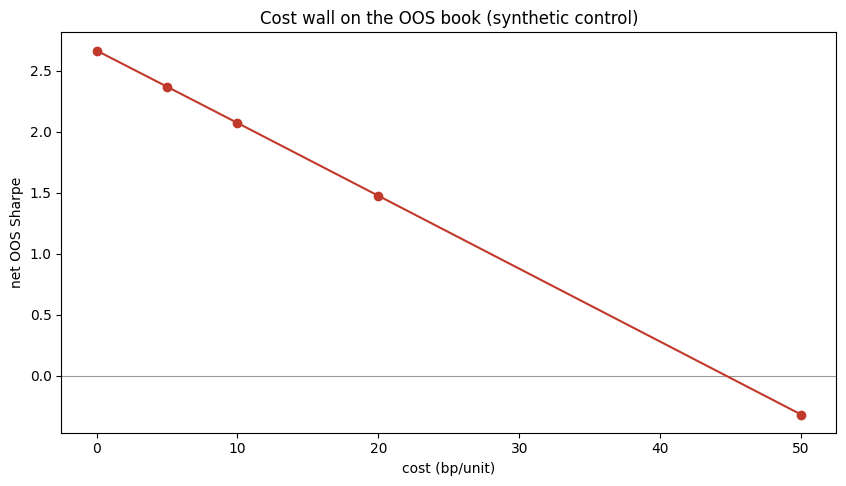

In [4]:
pos_oos = strategy.walk_forward_predictions(close, **WF)
print('Real OOS cost sweep (net Sharpe, ../docs/results.md):')
print('  0bp 0.897   5bp 0.628   10bp 0.359   20bp -0.178   50bp -1.772')
print(f'  turnover 0.91/day   break-even 16.68 bp')
cs = costs.cost_sweep(close, pos_oos)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net OOS Sharpe'); ax.set_title('Cost wall on the OOS book (synthetic control)')

## Beat 5 · The verdict

- **`NONE`** (4a): walk-forward OOS accuracy 0.512 ≈ 0.5, OOS Sharpe 0.90; in-sample 5.38 is the artefact.
- **`MIRAGE`** (4b): net @10 bp 0.36; no gross OOS edge for costs to erode.
- **Overfit `CONFIRMED`** (Beat 7): shuffled-label train accuracy 0.67 ≈ true 0.664.

> **Signal `NONE` · Tradability `MIRAGE` · Overfit? `CONFIRMED`** — the ML mirror of Crystal-Ball.

## Beat 6 · Could you trade it?

- **No.** Only the walk-forward number is investable, and it is a coin-flip gross, negative net.
- **Selection compounds it.** Tuning the architecture, features, or lookback against the test window is in-sample optimisation in disguise — the *deflated* Sharpe (López de Prado 2018) corrects the headline for the trials run; here it would push an already-zero edge below zero.
- **Capacity is moot.** With no edge there is nothing to scale.

## Beat 7 · Going further

### 7a · Worked complement — the shuffled-label control ([`../docs/extension.md`](../docs/extension.md))
Shuffle the targets so they carry **no** information, re-fit in-sample, and measure how well the net still reproduces them. If training accuracy stays well above 0.5, the in-sample fit is pure memorisation. Synthetic here; real tape in [`../docs/extension.md`](../docs/extension.md).

In [5]:
tab = extension.shuffled_label_control(close0, n_shuffles=4, **NET)  # on the NULL: nothing to learn
display(tab.round(3))
print('Real BTC (../docs/extension.md): true train acc', '0.664  vs shuffled', '0.67 -- memorisation, not skill.')

,train_accuracy,insample_sharpe
labels,,
true,0.624,3.787
shuffle_1,0.633,-0.345
shuffle_2,0.637,-0.170
shuffle_3,0.610,0.083
shuffle_4,0.640,-0.411


Real BTC (../docs/extension.md): true train acc 0.664  vs shuffled 0.67 -- memorisation, not skill.


> 💡 **In plain words.** Even when we randomise the labels — so there is *provably* nothing to predict — the net's in-sample training accuracy stays well above a coin-flip. It is fitting the labels by brute force. That is the entire in-sample 'edge', laid bare.

### 7b · The honest conclusion
The apparatus recovers a real signal when one exists (the control) and reports nothing when none does (the null, and real crypto out-of-sample). On daily crypto direction the black box is `NONE` / `MIRAGE` / overfitting-`CONFIRMED`. Together with Study 22 (Crystal-Ball), the pair shows the two classic ways a backtest lies: a look-ahead leak in the *feature*, and an over-parameterised learner memorising the *labels*. Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **Purged & embargoed CV** (López de Prado 2018) for honest model selection.
- **Deflated / probabilistic Sharpe** to correct for the number of configurations tried.
- **Intraday or richer features** — does any honest OOS edge ever appear?

PRs welcome — but report the *walk-forward* number, never the in-sample one.